# 01 — Exploratory Data Analysis

Exploration only. Data comes from `load_clean()` (validated, de-duplicated); features from `add_features()`. No pipeline logic lives here.

Every figure is saved to `reports/figures/eda_*.png` (dpi 150).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fraud_detection.config import load_config
from fraud_detection.data import load_clean
from fraud_detection.features import add_features
from fraud_detection.schema import FEATURE_COLUMNS, TARGET

config = load_config()
FIG_DIR = config.paths.figures_dir
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    path = FIG_DIR / f"eda_{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("saved", path.name)


df, summary = load_clean()
df = add_features(df)
fraud = df[TARGET] == 1
summary

{'rows_raw': 284807,
 'rows': 283726,
 'fraud_count': 473,
 'fraud_rate': 0.001667101358352777,
 'duplicates_dropped': 1081,
 'duplicate_fraud_dropped': 19}

## 1. Class distribution
Log scale — on a linear axis the fraud bar is invisible.

saved eda_class_distribution.png


Class
0    283253
1       473
Name: count, dtype: int64

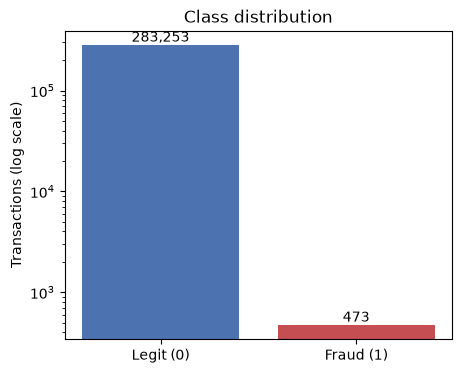

In [2]:
counts = df[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Legit (0)", "Fraud (1)"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("Transactions (log scale)")
ax.set_title("Class distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
save(fig, "class_distribution")
counts

## 2. Amount distribution: fraud vs legit
Log x-axis with log-spaced bins. Each bar is the share of that class's transactions, so the classes are comparable (plain density would be distorted by the unequal bin widths). Amount = 0 cannot be shown on a log axis, so those rows are counted separately.

Amount == 0 rows — legit: 1783  fraud: 25


saved eda_amount_distribution.png


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


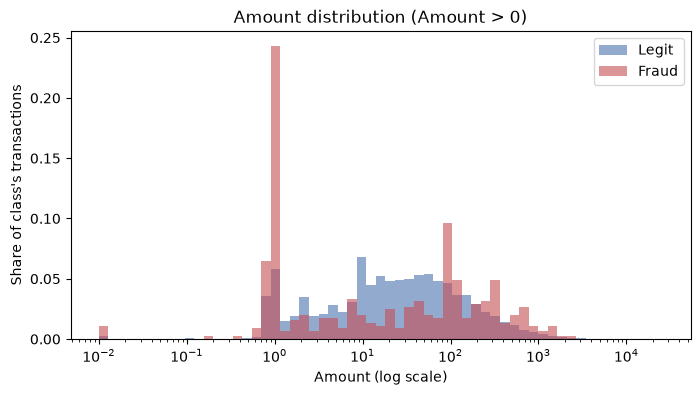

In [3]:
zero = df["Amount"] == 0
print("Amount == 0 rows — legit:", int((zero & ~fraud).sum()), " fraud:", int((zero & fraud).sum()))
bins = np.logspace(np.log10(0.01), np.log10(df["Amount"].max() + 1), 60)
fig, ax = plt.subplots(figsize=(8, 4))
for mask, label, color in [(~fraud, "Legit", "#4C72B0"), (fraud, "Fraud", "#C44E52")]:
    values = df.loc[mask & ~zero, "Amount"]
    # weights: each bar = share of that class (NOT density: log bins have unequal widths)
    ax.hist(values, bins=bins, weights=np.full(len(values), 1 / len(values)),
            alpha=0.6, label=label, color=color)
ax.set_xscale("log")
ax.set_xlabel("Amount (log scale)")
ax.set_ylabel("Share of class's transactions")
ax.set_title("Amount distribution (Amount > 0)")
ax.legend()
save(fig, "amount_distribution")
df.groupby(TARGET)["Amount"].describe()

## 3. Fraud rate by Amount bucket

saved eda_fraud_rate_by_amount.png


,transactions,fraud,fraud_rate_pct
Amount,,,
"[0.0, 1.0)",16765,66,0.393677
"[1.0, 10.0)",80108,172,0.214710
"[10.0, 50.0)",91937,54,0.058736
"[50.0, 100.0)",37640,56,0.148778
"[100.0, 250.0)",34437,54,0.156808
"[250.0, 500.0)",13380,37,0.276532
"[500.0, 1000.0)",6395,25,0.390930
"[1000.0, 5000.0)",3009,9,0.299103
"[5000.0, inf)",55,0,0.000000


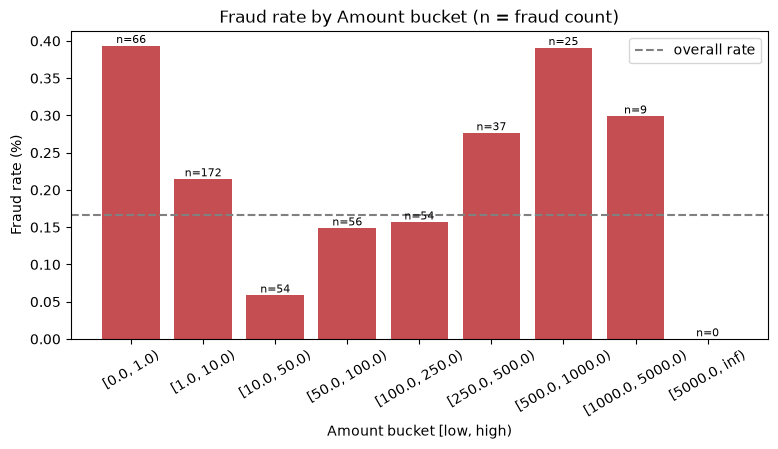

In [4]:
edges = [0, 1, 10, 50, 100, 250, 500, 1000, 5000, np.inf]
bucket = pd.cut(df["Amount"], bins=edges, right=False)
by_bucket = df.groupby(bucket, observed=True)[TARGET].agg(transactions="size", fraud="sum")
by_bucket["fraud_rate_pct"] = 100 * by_bucket["fraud"] / by_bucket["transactions"]

fig, ax = plt.subplots(figsize=(9, 4))
labels = [str(b) for b in by_bucket.index]
ax.bar(labels, by_bucket["fraud_rate_pct"], color="#C44E52")
ax.axhline(100 * fraud.mean(), ls="--", color="grey", label="overall rate")
for i, (rate, n) in enumerate(zip(by_bucket["fraud_rate_pct"], by_bucket["fraud"])):
    ax.text(i, rate, f"n={n}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Amount bucket [low, high)")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by Amount bucket (n = fraud count)")
ax.tick_params(axis="x", rotation=30)
ax.legend()
save(fig, "fraud_rate_by_amount")
by_bucket

## 4. Transactions and fraud per hour over the 2 days
`Time` is seconds since the first transaction, so the x-axis is *hours since start*, not clock time.

saved eda_hourly_volume.png


,transactions,fraud
count,48.000000,48.000000
mean,5910.958333,9.854167
std,2860.031900,7.756918
min,1082.000000,0.000000
25%,3089.500000,4.000000
50%,7689.000000,8.500000
75%,8248.500000,13.000000
max,9875.000000,43.000000


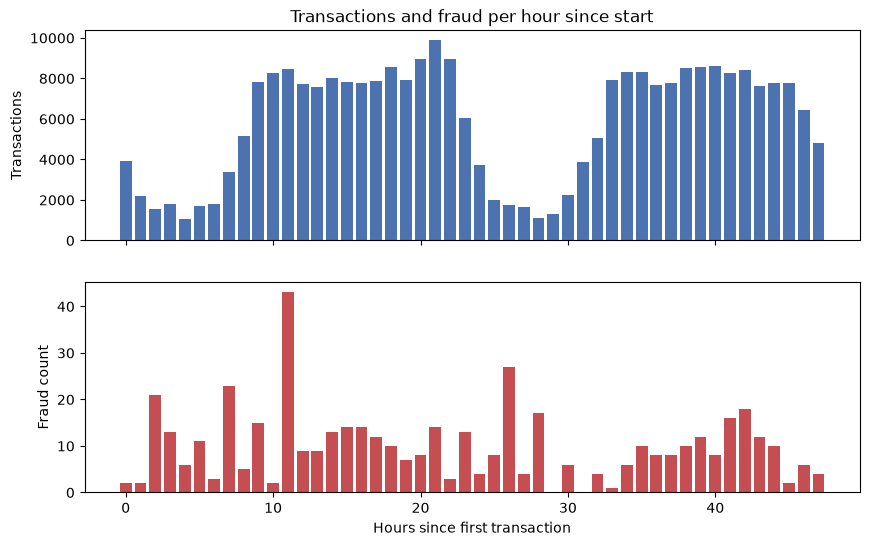

In [5]:
hours_since_start = (df["Time"] // 3600).astype(int)
per_hour = df.groupby(hours_since_start)[TARGET].agg(transactions="size", fraud="sum")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.bar(per_hour.index, per_hour["transactions"], color="#4C72B0")
ax1.set_ylabel("Transactions")
ax1.set_title("Transactions and fraud per hour since start")
ax2.bar(per_hour.index, per_hour["fraud"], color="#C44E52")
ax2.set_ylabel("Fraud count")
ax2.set_xlabel("Hours since first transaction")
save(fig, "hourly_volume")
per_hour.describe()

## 5. Top 10 features by |mean difference| between classes
Features are first standardised (z-score over all rows). Raw mean differences would be dominated by `Time` and `Amount` purely because of their units (seconds, euros), which says nothing about separability. The raw differences are printed below for reference.

saved eda_top10_mean_difference.png


,std_mean_diff,raw_mean_diff
V17,-7.684501,-6.474249
V14,-7.191247,-6.847614
V12,-6.145458,-6.112730
V10,-5.073300,-5.460937
V16,-4.588323,-4.008801
V3,-4.469101,-6.742452
V7,-4.224576,-5.186359
V11,3.653948,3.722350
V4,3.170048,4.483031
V18,-2.582098,-2.162191


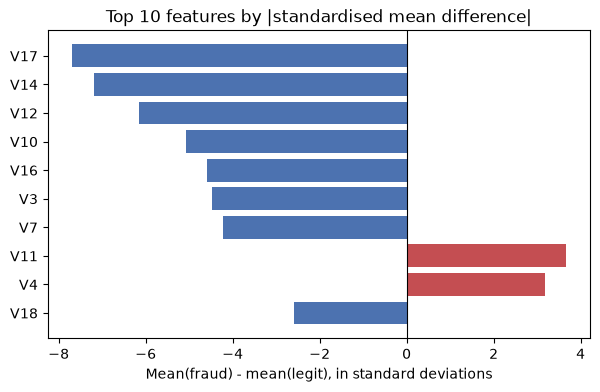

In [6]:
X = df[FEATURE_COLUMNS]
z = (X - X.mean()) / X.std()
std_diff = (z[fraud].mean() - z[~fraud].mean())
top10 = std_diff.abs().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#C44E52" if std_diff[f] > 0 else "#4C72B0" for f in top10.index]
ax.barh(top10.index[::-1], std_diff[top10.index][::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Mean(fraud) - mean(legit), in standard deviations")
ax.set_title("Top 10 features by |standardised mean difference|")
save(fig, "top10_mean_difference")

raw_diff = X[fraud].mean() - X[~fraud].mean()
pd.DataFrame({"std_mean_diff": std_diff[top10.index], "raw_mean_diff": raw_diff[top10.index]})

## 6. Correlation heatmap
Pearson correlation over all rows, including `Class`. V1–V28 are PCA components, so they are expected to be close to uncorrelated with each other.

saved eda_correlation_heatmap.png


V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64

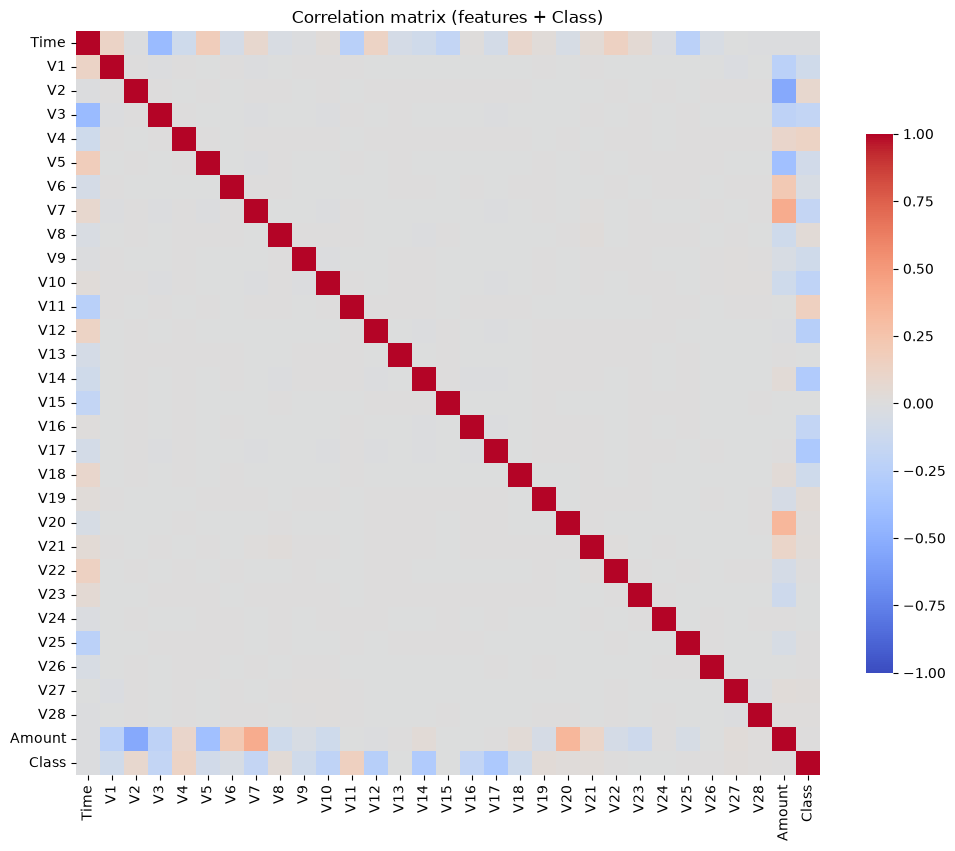

In [7]:
corr = df[FEATURE_COLUMNS + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"shrink": 0.7})
ax.set_title("Correlation matrix (features + Class)")
save(fig, "correlation_heatmap")
corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).head(10)

## Findings

_To be written by me after reading the figures above. Only state what the outputs show._

- Class imbalance: 
- Amount (fraud vs legit): 
- Fraud rate by Amount bucket: 
- Hourly pattern: 
- Most separating features: 
- Correlations: 
- Implications for modelling: 


In [ ]:
## Findings

- Fraud transactions are extremely rare compared with legitimate transactions, showing that the dataset is highly imbalanced.

- The transaction amount distributions for fraudulent and legitimate transactions have different shapes.

- Fraud activity varies across different hours of the day.

- A small number of anonymized V-features show larger differences between fraudulent and legitimate transactions.

- Some features show stronger correlations with other features in the correlation heatmap.